<a href="https://colab.research.google.com/github/Ranjan659/Cardamom-leaf-classifier/blob/main/01_data_setup_visualizaton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Cardamom Leaf vs Not-Leaf Classification

## Phase 1: Data Loading Pipeline

### Objectives
In this notebook we will:

1. Connect Google Drive to Colab
2. Load image dataset
3. Apply preprocessing transforms
4. Create batches using DataLoader
5. Visualize sample images

This is the first step before training a CNN model.

In [15]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Importing Required Libraries

We import:

- `torch` → Deep learning framework
- `torchvision` → Image datasets and transforms
- `matplotlib` → Visualization
- `os` → File handling

In [16]:
import os
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Dataset Setup

Dataset stored in Google Drive:

```text
cardamom_dataset/
└── train/
    ├── leaf/
    └── not_leaf/
```

We store the dataset location in:

```python
DATA_PATH = "/content/drive/MyDrive/cardamom_dataset/train"
```

This path tells PyTorch:

- "Go inside Google Drive"  
- "Find the dataset folder"  
- "Load images from the `train` directory"

---



In [17]:
DATA_PATH = "/content/drive/MyDrive/cardamom_dataset/train"

# Image Preprocessing

Neural networks require images of the same size.

We apply:

- `Resize(224,224)` → Standard input size
- `ToTensor()` → Converts image into tensor

In [18]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

#Load Dataset

`ImageFolder` reads all images and assigns labels automatically.

#How `ImageFolder` Works

`ImageFolder` automatically:

- Reads all images inside each folder  
- Uses folder names as class labels  
- Assigns numerical labels automatically

Example:

| Folder Name | Assigned Label |
|---|---|
| `leaf` | `0` |
| `not_leaf` | `1` |

So:

- Every image inside `leaf/` becomes class `0`
- Every image inside `not_leaf/` becomes class `1`

This makes dataset loading very easy for image classification tasks.

In [19]:
cardamom_leaves_dataset = datasets.ImageFolder(
    root=DATA_PATH,
    transform=transform
)

print("✅ Classes:", cardamom_leaves_dataset.classes)
print("✅ Label Mapping:", cardamom_leaves_dataset.class_to_idx)
print("✅ Total Images:", len(cardamom_leaves_dataset))

✅ Classes: ['leaf', 'not_leaf']
✅ Label Mapping: {'leaf': 0, 'not_leaf': 1}
✅ Total Images: 60


# Create DataLoader

The DataLoader:

- Creates batches
- Shuffles data
- Feeds images during training

Batch size = 8 means:
8 images are processed together.

In [20]:
dataloader = torch.utils.data.DataLoader(
    cardamom_leaves_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

# Inspect One Batch

We fetch one batch to verify:

- image shape
- labels
- preprocessing

In [21]:
images, labels = next(iter(dataloader))

print("✅ Batch Shape:", images.shape)
print("✅ Labels:", labels)

✅ Batch Shape: torch.Size([8, 3, 224, 224])
✅ Labels: tensor([1, 1, 0, 0, 1, 1, 1, 1])


# Visualize Images

PyTorch stores images in this format:

```text
(C, H, W)
```

Where:

- `C` → Color Channels  
  (`3` for RGB images)

- `H` → Image Height  
  (number of pixels vertically)

- `W` → Image Width  
  (number of pixels horizontally)

Example:

```text
(3, 224, 224)
```

means:

- 3 color channels (Red, Green, Blue)
- Height = 224 pixels
- Width = 224 pixels

However, `matplotlib` expects images in this format:

```text
(H, W, C)
```

So we use:

```python
permute(1, 2, 0)
```

to rearrange the dimensions before displaying the image.

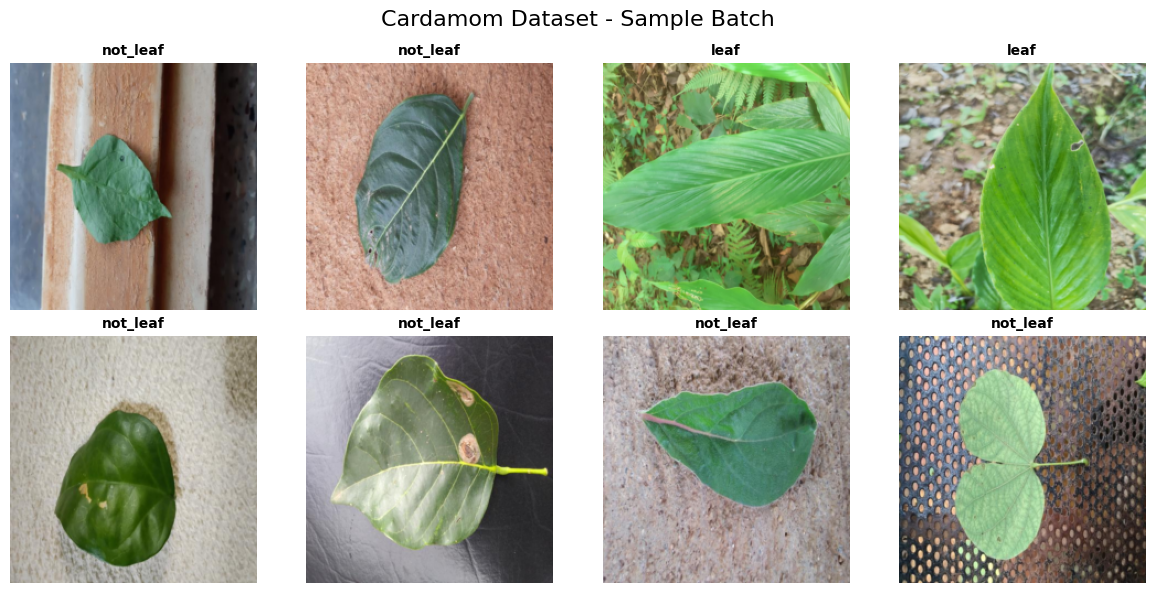

In [24]:
# Convert tensor into displayable image
def tensor_to_image(tensor):

    # Rearrange dimensions for display
    image = tensor.permute(1, 2, 0)

    # Keep pixel values between 0 and 1
    image = image.clamp(0, 1)

    return image

# Create figure and subplot grid with 2 rows and 4 columns
# figsize controls overall plot size
fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 6)
)


# axes contains all subplot boxes

# axes.flat converts the 2D grid into a simple 1D sequence for easier looping
# enumerate() adds index numbers:

# idx = image number
# ax  = current plot box
for idx, ax in enumerate(axes.flat):

    # Prevents going outside image list
    if idx < len(images):

        # Display image in current subplot
        ax.imshow(
            tensor_to_image(images[idx])
        )

        # Convert numeric label into class name
        class_name = (
            cardamom_leaves_dataset.classes[
                labels[idx]
            ]
        )

        # Add title above image
        ax.set_title(
            class_name,
            fontsize=10,
            fontweight="bold"
        )

        # Hide x-axis and y-axis
        ax.axis("off")


# Add title for entire figure
plt.suptitle(
    "Cardamom Dataset - Sample Batch",
    fontsize=16
)

# Automatically adjust spacing
# Prevents overlap between plots
plt.tight_layout()

# Display final visualization
plt.show()